In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" 

In [3]:
!pip install fastmri

In [2]:
import fastmri
from fastmri.data import transforms as T

In [3]:
file_path = r"D:\fastMRI\multicoil_train\2022061001_FLAIR01.h5"

with h5py.File(file_path, "r") as hf:
    print(list(hf.keys()))
    print(hf["kspace"].shape)
    print(hf["reconstruction_rss"].shape)

['ismrmrd_header', 'kspace', 'reconstruction_rss']
(18, 4, 256, 256)
(18, 256, 256)


In [4]:
with h5py.File(file_path, "r") as hf:
    kspace = hf["kspace"][()]
    rss_ref = hf["reconstruction_rss"][()]

slice_idx = kspace.shape[0] // 2
slice_kspace = kspace[slice_idx]
slice_rss = rss_ref[slice_idx]

print("slice_kspace:", slice_kspace.shape)
print("slice_rss:", slice_rss.shape)

slice_kspace: (4, 256, 256)
slice_rss: (256, 256)


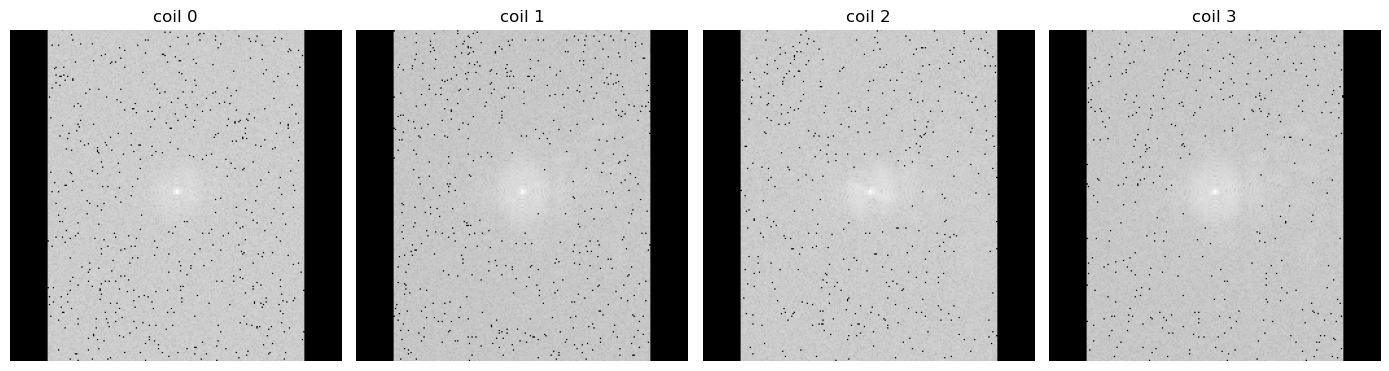

In [5]:
fig, axes = plt.subplots(1, slice_kspace.shape[0], figsize=(14, 4))
for c in range(slice_kspace.shape[0]):
    axes[c].imshow(np.log(np.abs(slice_kspace[c]) + 1e-9), cmap="gray")
    axes[c].set_title(f"coil {c}") #coil-space images with dots repr k-space
    axes[c].axis("off")
plt.tight_layout()
plt.show()

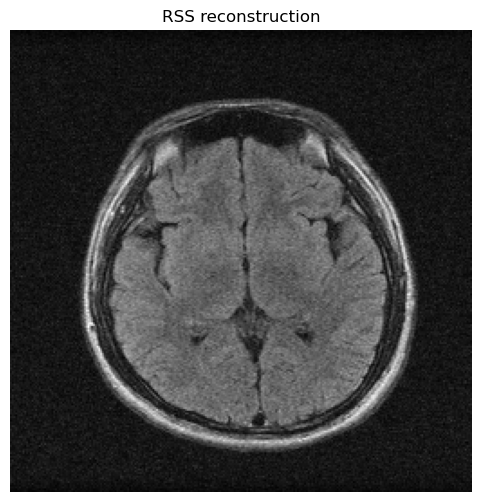

In [10]:
slice_kspace_t = T.to_tensor(slice_kspace)   #convert my numpy array to pytorch tensor (or 2D vs 3D)
coil_imgs = fastmri.ifft2c(slice_kspace_t)   #apply inv FFT
coil_mag = fastmri.complex_abs(coil_imgs)    #get magnitude
recon = fastmri.rss(coil_mag, dim=0)         #perform root mean square to combine coil wise images

plt.figure(figsize=(6, 6))
plt.imshow(recon.numpy(), cmap="gray")
plt.title("RSS reconstruction")
plt.axis("off")
plt.show()

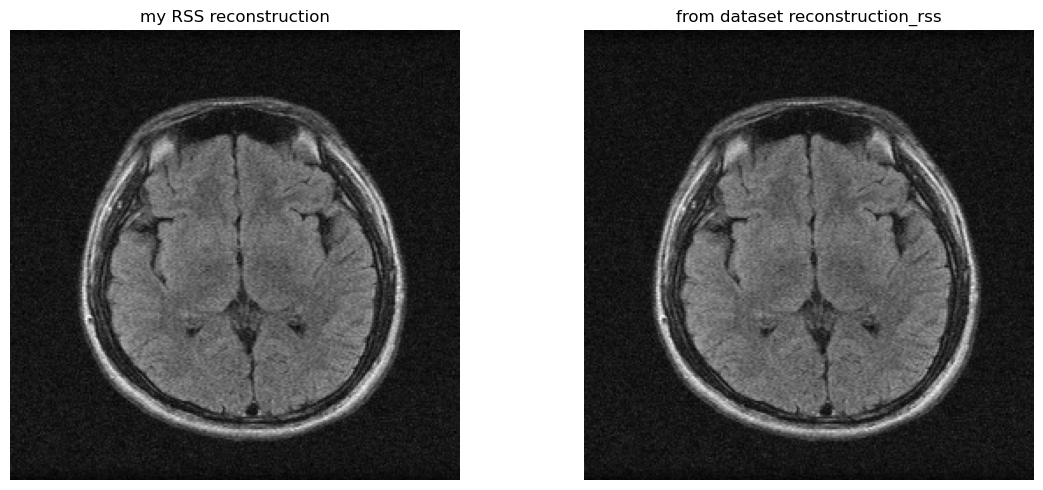

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(recon.numpy(), cmap="gray")
plt.title("my RSS reconstruction")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(slice_rss, cmap="gray")
plt.title("from dataset reconstruction_rss")
plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the basic reconstruction process for multi-coil brain MRI data. The raw k-space data were transformed into image space using a centered inverse Fourier transform, and the individual coil images were combined using root-sum-of-squares (RSS) coil combination.

The reconstructed RSS image was visually compared with the `reconstruction_rss` reference provided by fastMRI. The two images showed the same overall anatomical structure, confirming that the reconstruction and coil-combination pipeline was implemented correctly.

This experiment established the signal-processing foundation for the later learning-based experiments. In the subsequent notebooks, the fully sampled RSS reconstruction was used as the target, while artificially undersampled k-space was used to generate zero-filled inputs for neural-network reconstruction. fastMRI provides multi-coil k-space together with RSS reference reconstructions for this type of reconstruction research.

This notebook focused on understanding the reconstruction process rather than training a model or evaluating acceleration performance.